In [5]:
from typing import List, Dict, Any, Tuple

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import gridspec

from add_interpretability_stats import pretty_print_stats, get_generated_string
from utils import read_json

# Analysing model performance with and without noise

In [2]:
def calculate_accuracy(data: List[Dict[str, Any]]) -> Dict[str, Any]:
    if not data:
        return {'accuracy': 0, 'total_examples': 0, 'correct_answers': 0}

    total_examples = len(data)
    correct_answers = sum(1 for item in data if item.get('ans_match_after_norm', False))
    accuracy = correct_answers / total_examples

    return {
        'accuracy': accuracy,
        'total_examples': total_examples,
        'correct_answers': correct_answers,
        'incorrect_answers': total_examples - correct_answers
    }

def print_accuracy_report(data: List[Dict[str, Any]], title: str) -> None:
    results = calculate_accuracy(data)
    # return
    print("=" * 40)
    print(f"MODEL ACCURACY REPORT: {title}")
    print("=" * 40)
    print(f"Total Examples:    {results['total_examples']}")
    print(f"Correct Answers:   {results['correct_answers']}")
    print(f"Incorrect Answers: {results['incorrect_answers']}")
    print(f"Accuracy:          {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
    print("=" * 40)
    
    
def split_by_improvement(only_gold_data: List[Dict[str, Any]], noisy_gold_data: List[Dict[str, Any]]):
    assert len(only_gold_data) == len(noisy_gold_data)
    
    noise_improved_mask = [0] * len(only_gold_data)
    noise_worsened_mask = [0] * len(only_gold_data)
    noise_same_false_mask = [0] * len(only_gold_data)
    noise_same_true_mask = [0] * len(only_gold_data)
    
    assert len(only_gold_data) == len(noisy_gold_data)
    
    for i, (gold_entry, noisy_entry) in enumerate(zip(only_gold_data, noisy_gold_data)):
        if "error" in gold_entry or "error" in noisy_entry:
            continue
            
        assert gold_entry['gold_document_idx'] == noisy_entry['gold_document_idx'], \
            f"Mismatched gold_document_idx at {i}: {gold_entry['gold_document_idx']} != {noisy_entry['gold_document_idx']}"
        
        gold_correct = gold_entry['ans_match_after_norm']
        noisy_correct = noisy_entry['ans_match_after_norm']
        
        if not gold_correct and noisy_correct:
            # Performance improved with noise
            noise_improved_mask[i] = 1
        elif gold_correct and not noisy_correct:
            # Performance worsened with noise
            noise_worsened_mask[i] = 1
        elif not gold_correct and not noisy_correct:
            # Both incorrect (same poor performance)
            noise_same_false_mask[i] = 1
        else:  # gold_correct and noisy_correct
            # Both correct (same good performance)
            noise_same_true_mask[i] = 1
            
        # Print statistics
    total_entries = len(only_gold_data)
    print(f"\n=== Performance Analysis Statistics ===")
    print(f"Total entries: {total_entries}")
    print(f"")
    print(f"Noise improved performance:  {sum(noise_improved_mask):4d} ({sum(noise_improved_mask)/total_entries*100:5.1f}%)")
    print(f"Noise worsened performance:  {sum(noise_worsened_mask):4d} ({sum(noise_worsened_mask)/total_entries*100:5.1f}%)")
    print(f"Stayed incorrect:            {sum(noise_same_false_mask):4d} ({sum(noise_same_false_mask)/total_entries*100:5.1f}%)")
    print(f"Stayed correct:              {sum(noise_same_true_mask):4d} ({sum(noise_same_true_mask)/total_entries*100:5.1f}%)")
    print(f"")
            
    return noise_improved_mask, noise_worsened_mask, noise_same_false_mask, noise_same_true_mask



def combine_with_stats(
        only_gold_data: List[Dict[str, Any]],
        noisy_gold_data: List[Dict[str, Any]],
        only_gold_data_stats: List[Dict[str, Any]],
        noisy_gold_data_stats: List[Dict[str, Any]]
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    assert len(only_gold_data_stats) == len(noisy_gold_data_stats) == len(only_gold_data) == len(noisy_gold_data)
    
    combined_gold_data = []
    combined_noisy_gold_data = []
    
    for i in range(len(only_gold_data)):
        if "error" in only_gold_data_stats[i] or "error" in noisy_gold_data_stats[i]:
            continue
        
        assert only_gold_data[i]["gold_document_idx"] == noisy_gold_data[i]["gold_document_idx"] == only_gold_data_stats[i]["gold_document_idx"] == only_gold_data[i]["gold_document_idx"]
        
        combined_gold_data.append(only_gold_data[i] | only_gold_data_stats[i])
        combined_noisy_gold_data.append(noisy_gold_data[i] | noisy_gold_data_stats[i])
    
    return combined_gold_data, combined_noisy_gold_data  



In [3]:
only_gold_data = read_json("../data/csnlp/numdoc1_gold_at0_rand_answerless_info_all_extended.json")
noisy_gold_data = read_json("../data/csnlp/numdoc7_gold_at3_rand_answerless_info_all_extended.json")
noisy_gold_data[0].keys()

dict_keys(['example_id', 'query', 'prompt', 'document_indices', 'gold_document_idx', 'generated_answer', 'answers', 'ans_match_after_norm', 'gold_in_retrieved', 'ans_in_documents', 'prompt_tokens_len'])

In [4]:
only_gold_data_stats = read_json("../data/csnlp/numdoc1_gold_at0_rand_answerless_info_all_extended_interpr_stats.json")
noisy_gold_data_stats = read_json("../data/csnlp/numdoc7_gold_at3_rand_answerless_info_all_extended_interpr_stats.json")
only_gold_data_with_stats, noisy_gold_data_with_stats = combine_with_stats(only_gold_data, noisy_gold_data, only_gold_data_stats, noisy_gold_data_stats)
pretty_print_stats(only_gold_data_with_stats[2])

{
  example_id: 722054169493956493
  query: who is the sister of for king and country
  prompt: You are given a question and you MUST respond by EXTRACTING the answer (max 5 tokens) from one of the provided documents. If none of the documents contain the answer, respond with NO-RES.
Documents:
Document [20970754](Title: For King & Country (band)) The brothers were born in Sydney , and moved to Nashville , Tennessee in 1991 . The Smallbones are the younger brothers of Christian recording artist and speaker Rebecca St. James , and the brothers - in - law of Jacob Fink , former bassist for the band Foster the People .
Question: who is the sister of for king and country
Answer:
  document_indices (size: 1): ['20970754']
  gold_document_idx: 20970754
  generated_answer: REBECCA ST. JAMES
Explanation: In
  answers (size: 1): ['Rebecca St. James']
  ans_match_after_norm: True
  gold_in_retrieved: True
  ans_in_documents: True
  prompt_tokens_len: 150
  gold_doc_position: 0
  documents_token_p

In [47]:
print_accuracy_report(only_gold_data_with_stats, "ONLY GOLD DATA")
print_accuracy_report(noisy_gold_data_with_stats, "6 NOISES + GOLD DATA")

MODEL ACCURACY REPORT: ONLY GOLD DATA
Total Examples:    9983
Correct Answers:   5629
Incorrect Answers: 4354
Accuracy:          0.5639 (56.39%)
MODEL ACCURACY REPORT: 6 NOISES + GOLD DATA
Total Examples:    9983
Correct Answers:   4107
Incorrect Answers: 5876
Accuracy:          0.4114 (41.14%)


In [66]:
noise_improved_mask, noise_worsened_mask, noise_same_false_mask, noise_same_true_mask = split_by_improvement(only_gold_data_with_stats, noisy_gold_data_with_stats)
noise_same_mask = [a | b for a, b in zip(noise_same_false_mask, noise_same_true_mask)]


=== Performance Analysis Statistics ===
Total entries: 9983

Noise improved performance:   699 (  7.0%)
Noise worsened performance:  2221 ( 22.2%)
Stayed incorrect:            3655 ( 36.6%)
Stayed correct:              3408 ( 34.1%)



# Output metrics: confidence scores, entropy, top5mass

In [188]:
def print_output_metrics(only_gold_data, noisy_gold_data, noise_improved_mask, noise_worsened_mask, noise_same_mask):
    def get_mean_and_var(data, metric_name):
        means = [np.mean(item[metric_name]) for item in data]
        return np.mean(means), np.var(means)
    
    def get_masked_stats(data, mask, metric_name):
        masked_data = np.array(data, dtype=object)[mask]
        return get_mean_and_var(masked_data, metric_name)
    
    for metric_name in ['answer_tokens_output_confidences_softmax', 'answer_tokens_output_entropy', 'answer_tokens_output_top5mass']:
        print(f"\n{'='*60}")
        print(f"METRIC: {metric_name}")
        print(f"{'='*60}")
        
        # ALL DATA
        only_gold_mean, only_gold_var = get_mean_and_var(only_gold_data, metric_name)
        noisy_gold_mean, noisy_gold_var = get_mean_and_var(noisy_gold_data, metric_name)
        
        print(f"\nALL DATA:")
        print(f"  Only Gold  - Mean: {only_gold_mean:.4f}, Var: {only_gold_var:.4f}")
        print(f"  Noisy Gold - Mean: {noisy_gold_mean:.4f}, Var: {noisy_gold_var:.4f}")
        
        # IMPROVED CASES
        only_gold_improved_mean, only_gold_improved_var = get_masked_stats(only_gold_data, noise_improved_mask, metric_name)
        noisy_gold_improved_mean, noisy_gold_improved_var = get_masked_stats(noisy_gold_data, noise_improved_mask, metric_name)
        
        print(f"\nNOISE IMPROVED PERFORMANCE:")
        print(f"  Only Gold  - Mean: {only_gold_improved_mean:.4f}, Var: {only_gold_improved_var:.4f}")
        print(f"  Noisy Gold - Mean: {noisy_gold_improved_mean:.4f}, Var: {noisy_gold_improved_var:.4f}")
        
        # WORSENED CASES
        only_gold_worsened_mean, only_gold_worsened_var = get_masked_stats(only_gold_data, noise_worsened_mask, metric_name)
        noisy_gold_worsened_mean, noisy_gold_worsened_var = get_masked_stats(noisy_gold_data, noise_worsened_mask, metric_name)
        
        print(f"\nNOISE WORSENED PERFORMANCE:")
        print(f"  Only Gold  - Mean: {only_gold_worsened_mean:.4f}, Var: {only_gold_worsened_var:.4f}")
        print(f"  Noisy Gold - Mean: {noisy_gold_worsened_mean:.4f}, Var: {noisy_gold_worsened_var:.4f}")
        
        # SAME CASES
        only_gold_same_mean, only_gold_same_var = get_masked_stats(only_gold_data, noise_same_mask, metric_name)
        noisy_gold_same_mean, noisy_gold_same_var = get_masked_stats(noisy_gold_data, noise_same_mask, metric_name)
        
        print(f"\nNOISE DIDN'T CHANGE PERFORMANCE:")
        print(f"  Only Gold  - Mean: {only_gold_same_mean:.4f}, Var: {only_gold_same_var:.4f}")
        print(f"  Noisy Gold - Mean: {noisy_gold_same_mean:.4f}, Var: {noisy_gold_same_var:.4f}")


In [190]:
print_output_metrics(only_gold_data_with_stats, noisy_gold_data_with_stats, noise_improved_mask, noise_worsened_mask, noise_same_mask)


METRIC: answer_tokens_output_confidences_softmax

ALL DATA:
  Only Gold  - Mean: 0.7625, Var: 0.0063
  Noisy Gold - Mean: 0.8157, Var: 0.0046

NOISE IMPROVED PERFORMANCE:
  Only Gold  - Mean: 0.7685, Var: 0.0000
  Noisy Gold - Mean: 0.8146, Var: 0.0001

NOISE WORSENED PERFORMANCE:
  Only Gold  - Mean: 0.7703, Var: 0.0000
  Noisy Gold - Mean: 0.8199, Var: 0.0002

NOISE DIDN'T CHANGE PERFORMANCE:
  Only Gold  - Mean: 0.7761, Var: 0.0000
  Noisy Gold - Mean: 0.8368, Var: 0.0003

METRIC: answer_tokens_output_entropy

ALL DATA:
  Only Gold  - Mean: 0.5590, Var: 0.0512
  Noisy Gold - Mean: 0.4092, Var: 0.0270

NOISE IMPROVED PERFORMANCE:
  Only Gold  - Mean: 0.6653, Var: 0.0004
  Noisy Gold - Mean: 0.3441, Var: 0.0002

NOISE WORSENED PERFORMANCE:
  Only Gold  - Mean: 0.6541, Var: 0.0009
  Noisy Gold - Mean: 0.3516, Var: 0.0004

NOISE DIDN'T CHANGE PERFORMANCE:
  Only Gold  - Mean: 0.6185, Var: 0.0011
  Noisy Gold - Mean: 0.3753, Var: 0.0005

METRIC: answer_tokens_output_top5mass

ALL DATA:


# Attention scores

In [216]:

sns.set_style("whitegrid")
sns.set_palette("husl")


def plot_layered_metric_line_chart(only_gold_data, noisy_gold_data, metric_name, title: str, mask=None, ax=None):
    if mask is None:
        mask = np.ones(len(only_gold_data), dtype=bool)
        
    values1 = np.array([item[metric_name] for item in only_gold_data])[mask]
    values2 = np.array([item[metric_name] for item in noisy_gold_data])[mask]
    
    layers = np.arange(len(values1[0]))
    
    means1 = np.mean(values1, axis=0)
    means2 = np.mean(values2, axis=0)
    stds1 = np.std(values1, axis=0)
    stds2 = np.std(values2, axis=0)
    
    if ax is None:
        ax = plt.gca()
    
    color1, color2 = "goldenrod", "steelblue"
    
    ax.fill_between(layers, means1 - stds1, means1 + stds1, 
                   alpha=0.2, color=color1)
    ax.fill_between(layers, means2 - stds2, means2 + stds2, 
                   alpha=0.2, color=color2)
    
    ax.plot(layers, means1, color=color1, linewidth=1.5, 
           label='only gold', marker='o', markersize=2.5)
    ax.plot(layers, means2, color=color2, linewidth=1.5, 
           label='only gold + noise', marker='s', markersize=2.5)
    
    ax.set_xlabel('layer', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(frameon=True, fancybox=True, shadow=True)
    
    # remove top and right spines for cleaner look
    sns.despine(ax=ax)
    
    
def plot_4_data_cases(plot_function, only_gold_data, noisy_gold_data, metric_name, 
                     metric_display_name: str = None, figsize=(12, 8)):
    
    with sns.axes_style("whitegrid"):
        fig, axes = plt.subplots(2, 2, figsize=figsize, facecolor='white')
        
        plot_function(only_gold_data, noisy_gold_data, metric_name, 
                     title="All Data (N=9,983)", ax=axes[0][0])
        plot_function(only_gold_data, noisy_gold_data, metric_name, 
                     title="Noise Improved Results (N=699)", 
                     mask=noise_improved_mask, ax=axes[1][0])
        plot_function(only_gold_data, noisy_gold_data, metric_name, 
                     title="Noise Worsened Results (N=2,221)",
                     mask=noise_worsened_mask, ax=axes[1][1])
        plot_function(only_gold_data, noisy_gold_data, metric_name, 
                     title="Noise Didn't Change Results (N=7,063)", 
                     mask=noise_same_mask, ax=axes[0][1])
        
        if metric_display_name:
            fig.text(0.02, 0.5, metric_display_name, va='center', rotation='vertical', 
                    fontsize=11)
        
        plt.tight_layout()
        plt.subplots_adjust(left=0.1)  # make room for y-label
        plt.savefig(f"../data/charts/{metric_name}.png", bbox_inches='tight')
        plt.show()


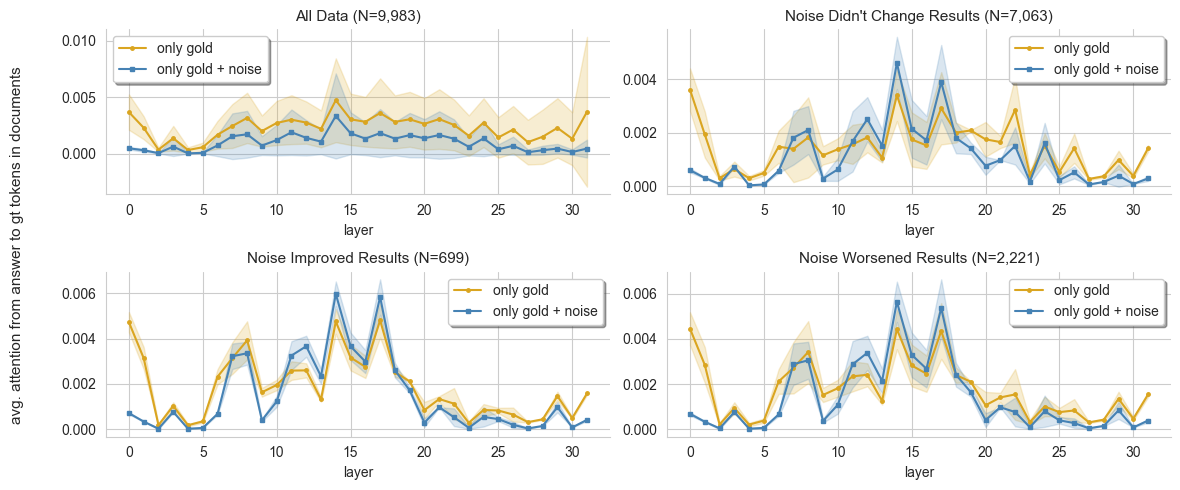

In [217]:
plot_4_data_cases(plot_layered_metric_line_chart, only_gold_data_with_stats, noisy_gold_data_with_stats, "answer_attention_to_gold_tokens_avg_1", metric_display_name="avg. attention from answer to gt tokens in documents", figsize=(12, 5))

# Internal activations

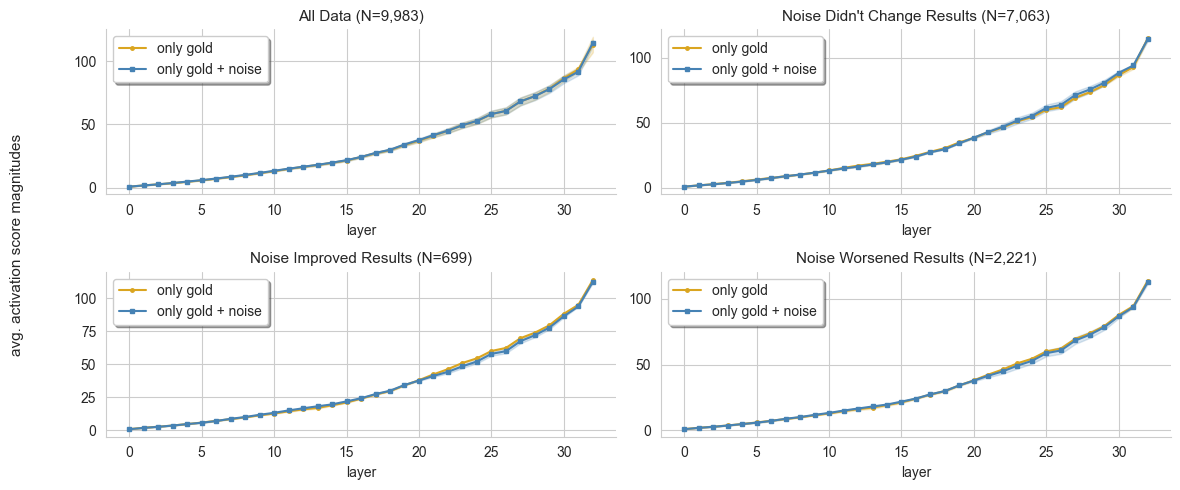

In [192]:
plot_4_data_cases(plot_layered_metric_line_chart, only_gold_data_with_stats, noisy_gold_data_with_stats, "activation_magnitudes", metric_display_name="avg. activation score magnitudes", figsize=(12, 5))
# as we can see, not much variance going on, gonna do it as a heatmap instead

In [220]:

def plot_4_heatmaps(only_gold_data, noisy_gold_data, metric_name, metric_display_name):
    cmap_style = "crest_r"
    cmap_style = "Spectral"
    cmap_style = "viridis"
    # cmap_style = "mako"
    only_gold_all = np.mean(np.array([item[metric_name] for item in only_gold_data]), axis=0)
    noisy_gold_all = np.mean(np.array([item[metric_name] for item in noisy_gold_data]), axis=0)
    
    only_gold_improved = np.mean(np.array([item[metric_name] for item in only_gold_data])[noise_improved_mask], axis=0)
    noisy_gold_improved = np.mean(np.array([item[metric_name] for item in noisy_gold_data])[noise_improved_mask], axis=0)
    
    only_gold_worsened = np.mean(np.array([item[metric_name] for item in only_gold_data])[noise_worsened_mask], axis=0)
    noisy_gold_worsened = np.mean(np.array([item[metric_name] for item in noisy_gold_data])[noise_worsened_mask], axis=0)
    
    only_gold_same = np.mean(np.array([item[metric_name] for item in only_gold_data])[noise_same_mask], axis=0)
    noisy_gold_same = np.mean(np.array([item[metric_name] for item in noisy_gold_data])[noise_same_mask], axis=0)
    
    data_all = np.array([only_gold_all, noisy_gold_all])
    data_improved = np.array([only_gold_improved, noisy_gold_improved])
    data_worsened = np.array([only_gold_worsened, noisy_gold_worsened])
    data_same = np.array([only_gold_same, noisy_gold_same])
    
    # Create figure with vertical layout
    fig = plt.figure(figsize=(6, 4))  # Increased height for vertical stacking
    gs = gridspec.GridSpec(5, 1, height_ratios=[0.3, 1, 1, 1, 1],  # Colorbar smaller than subplots
                           hspace=0.3, 
                           left=0.05, right=0.95, top=0.92, bottom=0.08)
    
    # Create subplot axes - all stacked vertically
    cax = fig.add_subplot(gs[0, 0])    # Horizontal colorbar at top
    ax1 = fig.add_subplot(gs[1, 0])    # All data
    ax2 = fig.add_subplot(gs[2, 0])    # Same
    ax3 = fig.add_subplot(gs[3, 0])    # Improved
    ax4 = fig.add_subplot(gs[4, 0])    # Worsened
    
    # Create heatmaps (all without colorbar except the last one)
    sns.heatmap(data_all, ax=ax1, cmap=cmap_style, cbar=False, square=True, 
                linewidths=0.5, linecolor='white')
    ax1.set_title('Data: all (N=9983)')
    ax1.set_yticklabels(['gold', 'gold + noise'], rotation=0)
    ax1.tick_params(labelbottom=False)
    
    sns.heatmap(data_same, ax=ax2, cmap=cmap_style, cbar=False, square=True, 
                linewidths=0.5, linecolor='white')
    ax2.set_title("Data: noise didn't change results cases (N=7063)")
    ax2.set_yticklabels(['gold', 'gold + noise'], rotation=0)
    ax2.tick_params(labelbottom=False)
    
    sns.heatmap(data_improved, ax=ax3, cmap=cmap_style, cbar=False, square=True, 
                linewidths=0.5, linecolor='white')
    ax3.set_title("Data: noise improved results (N=699)")
    ax3.set_yticklabels(['gold', 'gold + noise'], rotation=0)
    ax3.tick_params(labelbottom=False)
    
    # Last heatmap with horizontal colorbar
    sns.heatmap(data_worsened, ax=ax4, cmap=cmap_style, cbar=True, cbar_ax=cax, 
                square=True, linewidths=0.5, linecolor='white',
                cbar_kws={'orientation': 'horizontal'})
    ax4.set_title("Data: noise worsened results cases (N=2221)")
    ax4.set_yticklabels(['gold', 'gold + noise'], rotation=0)
    ax4.set_xlabel("layers")
    
    # Position colorbar labels on top
    cax.xaxis.set_label_position('top')
    cax.xaxis.tick_top()
    
    # Add main title
    fig.suptitle(metric_display_name, fontsize=16, y=1.1)
    plt.savefig(f"../data/charts/{metric_name}.png", bbox_inches='tight')
    
    plt.show()

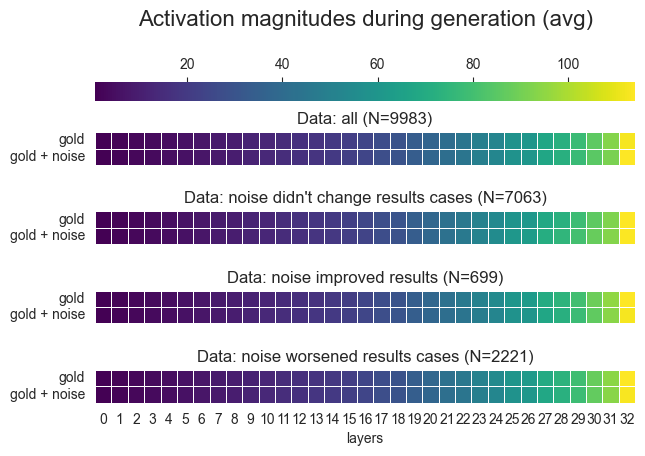

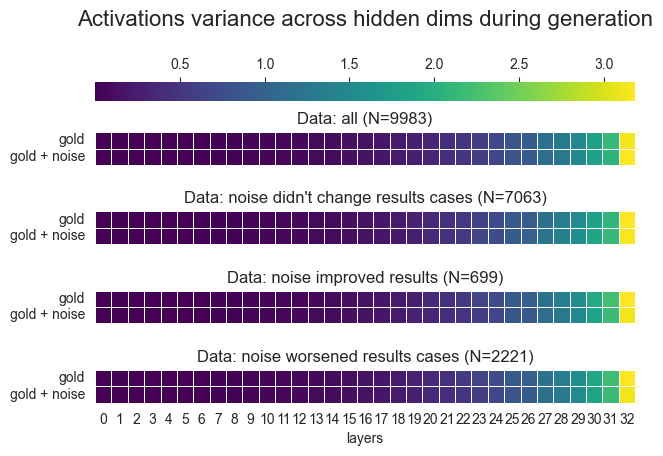

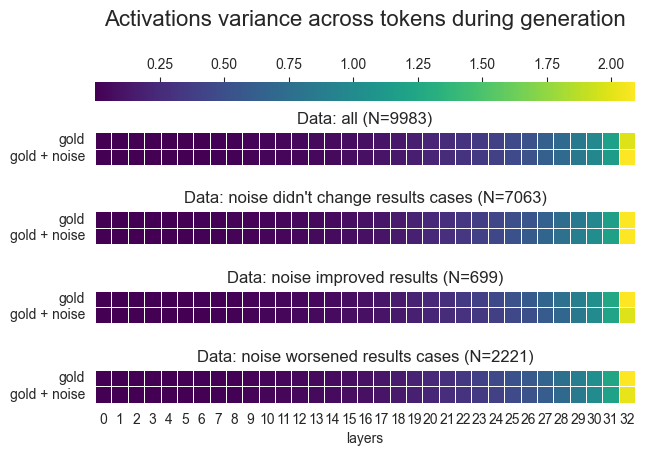

In [221]:
plot_4_heatmaps(only_gold_data_with_stats, noisy_gold_data_with_stats, 'activation_magnitudes', 'Activation magnitudes during generation (avg)')
plot_4_heatmaps(only_gold_data_with_stats, noisy_gold_data_with_stats, 'activations_variance_accross_hidden_dims', 'Activations variance across hidden dims during generation')
plot_4_heatmaps(only_gold_data_with_stats, noisy_gold_data_with_stats, 'activations_variance_accross_tokens', 'Activations variance across tokens during generation')
